In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Two mixing rules, one measured phase diagram (CO₂ / *n*-decane)

This notebook works **Illustration 11.2-5** and draws **Figure 11.2-6** — the
liquid-liquid phase boundary of carbon dioxide + *n*-decane, predicted from the same
Peng-Robinson equation of state with two different mixing rules, against the same
measurements.

**The illustration is a comparison, and its point is that one of the two answers is
bad.** The van der Waals one-fluid rule is drawn three times, at $k_{12} = 0.114$, 0.10
and 0.08, because one curve cannot make the argument: the whole coexistence curve slides
as that single constant is turned, and the reader is meant to watch it slide and see that
no setting puts it on the data. Only $k_{12} = 0.114$ has independent standing — it is
Table 9.4-1's value, regressed against *vapor-liquid* data at higher temperature. The
Wong-Sandler rule, with two parameters fitted at a *single* temperature, is said to give
"very good predictions at all other temperatures."

**Both claims are checked here rather than repeated.** The first holds, and more sharply
than the text puts it. At 0.114 the predicted two-liquid region has not closed anywhere
the experiment can see; lower $k_{12}$ enough to close it at about the right temperature
— 0.08 does, at 250.1 K against a measured 248.74 — and the low-temperature branch has
moved to 0.741 where the measurement says 0.577. **Getting the top right destroys the
bottom**, which is what the text means by "not of the correct shape."

The second claim holds too — but only after a question the illustration never has to ask
out loud, and getting it wrong the other way makes the Wong-Sandler curve look almost as
bad as the one it is supposed to beat.

**The question is: which quantity is the "temperature-independent parameter"?** The
book says the Wong-Sandler curve uses "temperature-independent parameters that have been
fit only to the data at 235.65 K." UNIQUAC's $\tau_{ij}$ is not that parameter —
$\ln\tau_{ij} = -(u_{ij}-u_{jj})/RT$, so $\tau$ carries a $1/T$ and the constant is the
energy behind it. Freeze the wrong one and the fit at 235.65 K is *identical*, the
solver converges, the tie line is exact, and the prediction at every other temperature
is wrong. That failure mode — right at the reference point and wrong everywhere else,
with nothing to warn you — is the reason this notebook exists in the form it does.

SIS = Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst / August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy import constants, optimize

from thermo.peng_robinson import PengRobinson
from thermo.pr_mixture import PRMixture
from thermo.activity_models import UNIQUAC
from thermo.wong_sandler import WongSandler
from thermo.charts import use_book_style
from thermo import lle

use_book_style()
BAR = constants.bar
K12_VDW = 0.114                      # SIS Table 9.4-1, CO2 / n-decane

# SIS Table 6.6-1's constants, which is what the illustrations were computed with.
# The database carries omega = 0.239 for CO2 against the book's 0.225, and that is
# worth 2 % in a pressure here -- shown in the Illustration 11.3-2
# notebook, which uses the same two fluids.
co2    = PengRobinson(Tc=304.2, Pc=7.376e6, omega=0.225, name="carbon dioxide")
decane = PengRobinson(Tc=617.6, Pc=2.108e6, omega=0.490, name="n-decane")

for c in (co2, decane):
    print(f"  {c.name:16s} Tc = {c.Tc:6.1f} K   Pc = {c.Pc/1e6:5.3f} MPa   "
          f"omega = {c.omega:.3f}")

  carbon dioxide   Tc =  304.2 K   Pc = 7.376 MPa   omega = 0.225
  n-decane         Tc =  617.6 K   Pc = 2.108 MPa   omega = 0.490


## The measurements

Nine points on the three-phase line, where the two liquids and the vapor coexist. The
last is the **upper critical end point**: the two liquid compositions have merged, the
liquid-liquid region has closed, and above it there is only one liquid.

**Data:** the table under Illustration 11.2-5, whose `Source:` line credits
B. Kulkarni, B. Zarah, K. Luks and J. Kohn, *Phase-Equilibria Behavior of System Carbon
Dioxide–n-Decane at Low Temperatures*, *J. Chem. Eng. Data* **19**, 92 (1974). The
citation is not in the figure caption, so looking for it there will fail.

In [3]:
# T (K), three-phase P (bar), x_CO2 in the decane-rich liquid (I) and in the
# CO2-rich liquid (II).
DATA = np.array([
    [235.65, 10.58, 0.577, 0.974], [236.15, 10.75, 0.582, 0.973],
    [238.15, 11.52, 0.602, 0.970], [240.15, 12.33, 0.627, 0.965],
    [242.15, 13.19, 0.659, 0.960], [244.15, 14.14, 0.695, 0.954],
    [246.15, 15.10, 0.734, 0.942], [248.15, 16.11, 0.783, 0.916],
    [248.74, 16.38, 0.850, 0.850]])
T_DATA, P_DATA, XI_DATA, XII_DATA = DATA.T
T0, P0, XI0, XII0 = DATA[0]                     # the reference isotherm, 235.65 K
T_UCEP = DATA[-1, 0]

print(f"  {len(DATA)} points from {T_DATA[0]:.2f} to {T_DATA[-1]:.2f} K")
print(f"  the two liquid branches meet at {T_UCEP:.2f} K and x_CO2 = {DATA[-1,2]:.3f}")
print(f"  the reference isotherm is {T0:.2f} K: x^I = {XI0:.3f}, x^II = {XII0:.3f}")

  9 points from 235.65 to 248.74 K
  the two liquid branches meet at 248.74 K and x_CO2 = 0.850
  the reference isotherm is 235.65 K: x^I = 0.577, x^II = 0.974


## Half one — the van der Waals one-fluid rule

$k_{12} = 0.114$ is not fitted to anything in this figure. It comes from Table 9.4-1,
where it was regressed against vapor-liquid data at higher temperatures, and the
question is whether it travels down here. `eos_binary_lle` finds the two coexisting
liquids from the equation of state's own Gibbs energy, so nothing is seeded from the
measurement.

The printed figure draws this rule three times — at $k_{12} = 0.114$, 0.10 and 0.08 — and those are
the values used throughout this half and in the finished figure, so that what is computed
here and what is drawn are the same three curves.

In [4]:
mix = PRMixture([co2, decane], kij=[[0.0, K12_VDW], [K12_VDW, 0.0]])

print(f"  van der Waals one-fluid, k12 = {K12_VDW}")
print(f"  {'T (K)':>7s} {'x^I meas':>9s} {'pred':>7s}   {'x^II meas':>10s} {'pred':>7s}")
for T, P, xI, xII in DATA:
    got = lle.eos_binary_lle(mix, T, P * BAR)
    if got is None:
        print(f"  {T:7.2f} {xI:9.3f} {'one phase':>7s}")
        continue
    print(f"  {T:7.2f} {xI:9.3f} {got[0][0]:7.3f}   {xII:10.3f} {got[1][0]:7.3f}")

  van der Waals one-fluid, k12 = 0.114
    T (K)  x^I meas    pred    x^II meas    pred
   235.65     0.577   0.538        0.974   0.997
   236.15     0.582   0.540        0.973   0.996
   238.15     0.602   0.552        0.970   0.996
   240.15     0.627   0.563        0.965   0.995
   242.15     0.659   0.574        0.960   0.995
   244.15     0.695   0.586        0.954   0.994
   246.15     0.734   0.597        0.942   0.993
   248.15     0.783   0.609        0.916   0.992
   248.74     0.850   0.612        0.850   0.992


**Too wide at the bottom and too tall at the top.** At 235.65 K the model puts the
decane-rich liquid at 0.538 against a measured 0.577 and the CO₂-rich one at 0.997
against 0.974 — and it is still predicting two liquids at 248.74 K, where the
measurement says they have already merged.

The illustration's claim is about *where* they merge, so measure that. March up in
temperature until the two branches meet.

In [5]:
def three_phase(model_of_T, T):
    """(P, x^I, x^II) on the model's own vapor-liquid-liquid line, or None above it.

    The upper critical end point is where the two liquids merge *on the three-phase
    line*, so the pressure is not free to choose -- it is whatever makes the vapor
    coexist too. `eos_vlle_binary` solves all four unknowns at once, which is the
    calculation Illustration 11.3-2 does for this same mixture.
    """
    with warnings.catch_warnings():
        # Above the three-phase line the vapor equation has only the trivial root
        # y = x^II, and `eos_vlle_binary` says so and returns None. That is the
        # signal this function is looking for, so the message is not news here.
        warnings.simplefilter("ignore", RuntimeWarning)
        try:
            got = lle.eos_vlle_binary(model_of_T(T), T)
        except Exception:
            return None
    if got is None or got[3][0] - got[2][0] < 2e-3:
        return None
    return got[0], got[2][0], got[3][0]

def top_of_three_phase_line(model_of_T, lo, hi, tol=1e-3):
    """Highest T at which the three-phase calculation still returns two liquids.

    This is the top of the *computable* three-phase line, which is not the same
    thing as a critical end point. Read the gap it comes back with: if the two
    liquid compositions have merged there, the line ended at a critical end point;
    if they are still far apart, it ended because the vapor root was lost, and the
    two-liquid region continues above with the calculation unable to follow it.
    """
    if three_phase(model_of_T, lo) is None:
        return None
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if three_phase(model_of_T, mid) else (lo, mid)
    _, xI, xII = three_phase(model_of_T, lo)
    return lo, xI, xII

print(f"  {'':>8s} {'top of the 3-phase line':>26s}   {'at 235.65 K':>19s}")
print(f"  {'k12':>8s} {'T (K)':>8s} {'x^I':>7s} {'x^II':>7s} {'gap':>6s}   "
      f"{'x^I':>9s} {'x^II':>9s}")
for k in (0.114, 0.100, 0.090, 0.080):
    m = PRMixture([co2, decane], kij=[[0.0, k], [k, 0.0]])
    top = top_of_three_phase_line(lambda T, m=m: m, 250.0, 320.0)
    lo = lle.eos_binary_lle(m, T0, P0 * BAR)
    if top is None:
        print(f"  {k:8.3f}   no two-liquid region on the three-phase line")
        continue
    T_top, xI, xII = top
    print(f"  {k:8.3f} {T_top:8.1f} {xI:7.3f} {xII:7.3f} {xII - xI:6.3f}   "
          f"{lo[0][0]:9.3f} {lo[1][0]:9.3f}")
print(f"  {'measured':>8s} {T_UCEP:8.2f} {DATA[-1,2]:7.3f} {DATA[-1,3]:7.3f} "
      f"{0.0:6.3f}   {XI0:9.3f} {XII0:9.3f}")

              top of the 3-phase line           at 235.65 K
       k12    T (K)     x^I    x^II    gap         x^I      x^II


     0.114    298.9   0.829   0.926  0.097       0.538     0.997


     0.100    272.2   0.884   0.892  0.008       0.611     0.994


     0.090    260.3   0.896   0.898  0.002       0.671     0.990


     0.080    250.1   0.899   0.912  0.013       0.741     0.982
  measured   248.74   0.850   0.850  0.000       0.577     0.974


**Read the `gap` column before reading the temperature.** At Table 9.4-1's
$k_{12} = 0.114$ the three-phase calculation stops at 298.9 K with the two liquids still
**0.10 apart in mole fraction** — they have not merged, and they were not about to. That
number is where the *calculation* ends, not where the model's two liquids become
identical: as CO₂'s critical temperature (304.2 K) is approached the vapor root is lost
and the three-phase line can no longer be followed. Held at a fixed 60 bar instead, with
the vapor out of the way, this model's two liquids survive past **420 K**.

**So 298.9 K is not a predicted critical solution temperature**, and quoting it as one
flatters the model. The honest statement is stronger: at $k_{12} = 0.114$ the two-liquid
region does not close at all within reach of the experiment.

**And here is why no $k_{12}$ fixes it — the last row is the one to look at.**
Lowering $k_{12}$ *does* bring a genuine critical end point down, and by 0.080 it lands
at 250.1 K, within 1.4 K of the measurement. The knob works. But at that same $k_{12}$
the 235.65 K tie line has gone from 0.538 to **0.741** against a measured 0.577, and the
critical composition is 0.90 against 0.850. **Getting the top right has destroyed the
bottom.** The two ends of the curve move together and the measurement needs them to move
apart.

That is what "no choice for the binary interaction parameter" means, and it is a
statement about shape rather than size: the one-fluid rule makes $a_{\rm mix}$ a
quadratic in composition, and a quadratic excess Gibbs energy is symmetric in a way this
mixture is not. One constant sets the width of the region; nothing sets its skew.

This is a limit to state clearly rather than be embarrassed by. One cubic equation with
one adjustable constant gives good vapor-liquid predictions for this mixture over a wide
range of temperature and pressure *and* gets the qualitative existence of a
liquid-liquid region right. What it cannot do is get that region quantitatively right at
the same time, and the reason is structural: the one-fluid rule makes $a_{\rm mix}$ a
quadratic in composition, which is not enough freedom to describe a strongly
non-quadratic excess Gibbs energy.

## Half two — the Wong-Sandler rule

Section 9.9's mixing rule puts an activity coefficient model *inside* the equation of
state, so the excess Gibbs energy can be whatever that model can describe while the
equation of state still handles density and the vapor phase. Here the model is UNIQUAC.

### The size parameters come from structure, and from the right table

UNIQUAC's $r$ and $q$ are not fitted. They are sums of group contributions, and
*n*-decane is 2 CH₃ + 8 CH₂.

In [6]:
from thermo.data import load_unifac_subgroups

orig = load_unifac_subgroups("original").set_index("subgroup_name")
dort = load_unifac_subgroups().set_index("subgroup_name")

def rq(counts, table):
    r = sum(n * table.loc[g, "R"] for g, n in counts.items())
    q = sum(n * table.loc[g, "Q"] for g, n in counts.items())
    return r, q

DECANE_GROUPS = {"CH3": 2, "CH2": 8}
r_o, q_o = rq(DECANE_GROUPS, orig)
r_d, q_d = rq(DECANE_GROUPS, dort)

print("  n-decane = 2 CH3 + 8 CH2")
print(f"    original UNIFAC R/Q  ->  r = {r_o:.4f}, q = {q_o:.4f}   <- the UNIQUAC values")
print(f"    Dortmund  UNIFAC R/Q ->  r = {r_d:.4f}, q = {q_d:.4f}   <- q > r, impossible")

R_CO2, Q_CO2 = 1.296, 1.261          # Prausnitz; CO2 is not an alkane group
R_C10, Q_C10 = r_o, q_o

  n-decane = 2 CH3 + 8 CH2
    original UNIFAC R/Q  ->  r = 7.1974, q = 6.0160   <- the UNIQUAC values
    Dortmund  UNIFAC R/Q ->  r = 6.3250, q = 7.7864   <- q > r, impossible


**The two tables are not interchangeable, and only one of them is UNIQUAC's.** The
original UNIFAC $R$ and $Q$ *are* the classical UNIQUAC group parameters — Bondi's van
der Waals group volumes and surface areas — so summing them gives *n*-decane's literature
$r = 7.1974$ and $q = 6.0160$ exactly. The modified (Dortmund) $R$ and $Q$ are fitted
quantities belonging to a different model; summed the same way they give $q > r$, which
no real molecule has. Chapter 9's Table 9.5-2 is the Dortmund set, and it says in its own
footnote that $R$ and $Q$ must come from the same parameter set as the interaction
parameters used with them. This is that rule, biting.

### Fitting two parameters to one tie line

Solving a liquid-liquid equilibrium inside a least-squares loop is slow and fragile.
There is no need: at 235.65 K the two coexisting compositions are *known*, so equality of
fugacity is two equations in the two unknowns, with no inner phase-equilibrium solve at
all. That is precisely "parameters fitted to the 235.65 K data," it runs in milliseconds,
and it makes the reference tie line exact by construction rather than approximately
right.

In [7]:
XI_VEC  = np.array([XI0,  1 - XI0])
XII_VEC = np.array([XII0, 1 - XII0])

def build(tau12, tau21, kij, T_ref=T0):
    """Peng-Robinson + Wong-Sandler + UNIQUAC, with tau declared at T_ref."""
    uq = UNIQUAC(r=[R_CO2, R_C10], q=[Q_CO2, Q_C10],
                 tau12=tau12, tau21=tau21).at_T(T_ref)
    return WongSandler([co2, decane], uq, kij=kij)

def fit_tie_line(kij, starts=(-2.5, -1.5, -0.7, 0.0, 0.7)):
    """tau12, tau21 that put the measured 235.65 K tie line in equilibrium."""
    def resid(p):
        try:
            e = build(*np.exp(p), kij)
            a = np.log(XI_VEC)  + np.asarray(e.ln_phi(XI_VEC,  T0, P0 * BAR,
                                                      phase="liquid"), float)
            b = np.log(XII_VEC) + np.asarray(e.ln_phi(XII_VEC, T0, P0 * BAR,
                                                      phase="liquid"), float)
        except Exception:
            return [9.0, 9.0]
        r = a - b
        return list(r) if np.all(np.isfinite(r)) else [9.0, 9.0]

    found = []
    for l12 in starts:
        for l21 in starts:
            s = optimize.least_squares(resid, [l12, l21], xtol=1e-14, ftol=1e-14)
            if np.sum(np.asarray(s.fun) ** 2) < 1e-18:
                t = tuple(np.exp(s.x))
                if not any(abs(t[0] - u[0]) < 1e-6 and abs(t[1] - u[1]) < 1e-6
                           for u in found):
                    found.append(t)
    return found

TAU12, TAU21 = fit_tie_line(K12_VDW)[0]
A12, A21 = -T0 * np.log(TAU12), -T0 * np.log(TAU21)

print(f"  k_ij = {K12_VDW}, fitted to the {T0} K tie line alone")
print(f"    tau12 = {TAU12:.4f}   tau21 = {TAU21:.4f}      (at {T0} K)")
print(f"    a12   = {A12:.1f} K   a21   = {A21:.1f} K      (the energies, u_ij - u_jj over R)")
print(f"  25 starts, {len(fit_tie_line(K12_VDW))} distinct solution: the fit is unique")

  k_ij = 0.114, fitted to the 235.65 K tie line alone
    tau12 = 0.3917   tau21 = 0.1847      (at 235.65 K)
    a12   = 220.8 K   a21   = 398.1 K      (the energies, u_ij - u_jj over R)
  25 starts, 1 distinct solution: the fit is unique


### The question the illustration does not ask out loud

Those two lines print **the same information twice**. $a_{ij} = -T_0\ln\tau_{ij}$ is a
one-to-one map, so at 235.65 K the two descriptions are identical and the fit cannot tell
them apart. They are different models everywhere else:

$$\tau_{ij}\ \text{constant} \qquad\text{versus}\qquad
  \tau_{ij} = \exp(-a_{ij}/T),\quad a_{ij}\ \text{constant}$$

The book's own definition settles it — Section 9.5 defines
$\ln\tau_{ij} = -(u_{ij}-u_{jj})/RT$, so the temperature-independent parameter is the
**interaction energy**, and $\tau$ moves. That is also the universal convention in
process simulators, where the tabulated UNIQUAC binary parameters *are* the energies and
"temperature-independent" means no $b_{ij}/T$ or $c_{ij}\ln T$ terms have been added to
them.

**One sentence in the illustration reads the other way.**
Section 11.2 goes on: *"The success of this more complicated mixing rule with
temperature-independent parameters results from the fact that there is a temperature
dependence built into the equation of state."* Taken alone that could be read as saying
the activity model contributes no temperature dependence at all — i.e. that $\tau$ itself
is frozen. It is better read as a contrast with the sentence before it, which says a bare
UNIQUAC would need *parameters that are functions of temperature* to do as well: the
equation of state supplies what the $\exp(-a/T)$ alone cannot. The calculation below is
the tiebreaker, and it is not close.

Run both and compare against the data.

In [8]:
def locus(tau12, tau21, kij, energies_fixed):
    """Predicted (x^I, x^II) at every measured temperature."""
    a12, a21 = -T0 * np.log(tau12), -T0 * np.log(tau21)
    out = []
    for T, P, _, _ in DATA:
        if energies_fixed:
            e = build(np.exp(-a12 / T), np.exp(-a21 / T), kij, T_ref=T)
        else:
            e = build(tau12, tau21, kij, T_ref=T)     # declared at T: no warning
        try:
            got = lle.eos_binary_lle(e, T, P * BAR, n=81)
        except Exception:
            got = None
        out.append(None if got is None else (got[0][0], got[1][0]))
    return out

def rms_max(pred, upto=8):
    """Deviation in mole fraction over the sub-critical points, both branches."""
    d = [(p[0] - m[2], p[1] - m[3])
         for p, m in zip(pred[:upto], DATA[:upto]) if p is not None]
    if len(d) < upto:
        return None, None
    return (float(np.sqrt(np.mean([a * a + b * b for a, b in d]) / 2)),
            max(max(abs(a), abs(b)) for a, b in d))

frozen_tau = locus(TAU12, TAU21, K12_VDW, energies_fixed=False)
frozen_a   = locus(TAU12, TAU21, K12_VDW, energies_fixed=True)

print(f"  {'T (K)':>7s} | {'x^I':>8s} {'x^II':>8s} measured | "
      f"{'tau fixed':>18s} | {'energies fixed':>18s}")
for (T, P, xI, xII), ft, fa in zip(DATA, frozen_tau, frozen_a):
    f = f"{ft[0]:8.3f} {ft[1]:9.3f}" if ft else f"{'one phase':>18s}"
    a = f"{fa[0]:8.3f} {fa[1]:9.3f}" if fa else f"{'one phase':>18s}"
    print(f"  {T:7.2f} | {xI:8.3f} {xII:8.3f}          | {f} | {a}")

for tag, pred in (("tau fixed", frozen_tau), ("energies fixed", frozen_a)):
    rms, mx = rms_max(pred)
    print(f"\n  {tag:15s} rms = {rms:.4f}, worst = {mx:.4f}"
          if rms is not None else f"\n  {tag:15s} does not split at all nine temperatures")

    T (K) |      x^I     x^II measured |          tau fixed |     energies fixed
   235.65 |    0.577    0.974          |    0.577     0.974 |    0.577     0.974
   236.15 |    0.582    0.973          |    0.578     0.973 |    0.582     0.973
   238.15 |    0.602    0.970          |    0.582     0.971 |    0.603     0.969
   240.15 |    0.627    0.965          |    0.585     0.968 |    0.626     0.963
   242.15 |    0.659    0.960          |    0.588     0.965 |    0.652     0.955
   244.15 |    0.695    0.954          |    0.590     0.961 |    0.681     0.945
   246.15 |    0.734    0.942          |    0.592     0.956 |    0.715     0.929
   248.15 |    0.783    0.916          |    0.593     0.951 |    0.764     0.899
   248.74 |    0.850    0.850          |    0.594     0.949 |    0.786     0.882

  tau fixed       rms = 0.0688, worst = 0.1895

  energies fixed  rms = 0.0099, worst = 0.0191


**A factor of seven in the rms, from a distinction that is invisible at the reference
temperature.** With the energies held fixed every sub-critical composition lands within
0.02 of the measurement on both branches, across 13 K, from two parameters fitted at one
temperature and a $k_{ij}$ taken from Table 9.4-1 without refitting. That is what "very
good predictions at all other temperatures" means, and the book's claim holds.

With $\tau$ held fixed instead, the same fit — the same numbers, at the reference
temperature — gives a curve that is better than the one-fluid rule and not good.

**`thermo` now warns about this.** `UNIQUAC`, `NRTL` and `Wilson` store a ratio that
hides a $1/T$, so evaluating one instance at a second temperature raises a
`FrozenParameterWarning`. The cell above never triggers it, because it builds a fresh
model at each temperature — which is also the clearest way to write it, since the $1/T$
ends up on the page next to the equation that justifies it.

### Is the answer sensitive to $k_{ij}$?

The Wong-Sandler rule has a second binary parameter, and the tie-line fit does not
determine it — every $k_{ij}$ admits a $(\tau_{12}, \tau_{21})$ that reproduces the
reference tie line exactly. If the good agreement above depended on a knife-edge choice
it would not mean much.

In [9]:
print(f"  {'k_ij':>6s} {'a12 (K)':>8s} {'a21 (K)':>8s} {'rms in x':>9s} {'worst':>7s}")
for kij in (0.00, 0.05, 0.10, K12_VDW, 0.125, 0.135, 0.15, 0.20):
    sols = fit_tie_line(kij)
    if not sols:
        print(f"  {kij:6.3f}   no parameters put the tie line in equilibrium")
        continue
    t12, t21 = sols[0]
    rms, mx = rms_max(locus(t12, t21, kij, energies_fixed=True))
    mark = "   <- Table 9.4-1" if abs(kij - K12_VDW) < 1e-9 else ""
    if rms is None:
        print(f"  {kij:6.3f} {-T0*np.log(t12):8.1f} {-T0*np.log(t21):8.1f}"
              f"   does not split at all nine T{mark}")
    else:
        print(f"  {kij:6.3f} {-T0*np.log(t12):8.1f} {-T0*np.log(t21):8.1f}"
              f" {rms:9.4f} {mx:7.4f}{mark}")

    k_ij  a12 (K)  a21 (K)  rms in x   worst


   0.000    344.9    336.7    0.0505  0.1234


   0.050    287.5    355.5    0.0346  0.0880


   0.100    235.0    386.3    0.0161  0.0371


   0.114    220.8    398.1    0.0099  0.0191   <- Table 9.4-1


   0.125    209.9    408.6    0.0052  0.0108


   0.135    200.1    419.5    0.0024  0.0041


   0.150    185.5    438.4    0.0058  0.0140


   0.200    139.1    544.7    0.0305  0.0599


**The whole family from 0.10 to 0.15 is good**, with an optimum near 0.135 that is
better still. This notebook keeps $k_{ij} = 0.114$ — **the same number the van der Waals
half uses**, taken from Table 9.4-1 and not refitted — so the two curves in Figure 11.2-6
differ *only* in the mixing rule, which is the comparison the illustration is making.
Choosing 0.135 would make the agreement look better and would no longer be a prediction
from data at one temperature.

**The book prints no UNIQUAC parameters for this figure**, so the numbers above are
this notebook's, obtained by the procedure the text describes rather than recovered from
the printed curve. They are not claimed to be the ones that drew the printed curve.

### Where the model must fail, and does

The last row is the upper critical end point itself, and the agreement there is much
worse than anywhere else. That is not a defect in the fit.

In [10]:
def ws_at(T, kij=K12_VDW):
    return build(np.exp(-A12 / T), np.exp(-A21 / T), kij, T_ref=T)

T_ws,  xI_top_ws,  xII_top_ws  = top_of_three_phase_line(ws_at, 248.0, 256.0)
T_vdw, xI_top_vdw, xII_top_vdw = top_of_three_phase_line(lambda T: mix, 250.0, 320.0)

print(f"  {'':28s} {'T (K)':>7s} {'x^I':>7s} {'x^II':>7s} {'gap':>7s}")
print(f"  {'measured, liquids merge':28s} {T_UCEP:7.2f} {DATA[-1,2]:7.3f} "
      f"{DATA[-1,3]:7.3f} {0.0:7.3f}")
print(f"  {'Wong-Sandler, liquids merge':28s} {T_ws:7.2f} {xI_top_ws:7.3f} "
      f"{xII_top_ws:7.3f} {xII_top_ws - xI_top_ws:7.3f}   <- a real critical end point")
print(f"  {'one-fluid, vapor root lost':28s} {T_vdw:7.2f} {xI_top_vdw:7.3f} "
      f"{xII_top_vdw:7.3f} {xII_top_vdw - xI_top_vdw:7.3f}   <- still wide open")

print(f"\n  Wong-Sandler critical end point is {T_ws - T_UCEP:+.1f} K from the measurement")

_, xI, xII = three_phase(ws_at, T_UCEP)
print(f"\n  at the measured end point, {T_UCEP:.2f} K, where x^I = x^II = {DATA[-1,2]:.3f},")
print(f"  Wong-Sandler still gives x^I = {xI:.3f}, x^II = {xII:.3f}"
      f" -- a dome that has not quite closed")

                                 T (K)     x^I    x^II     gap
  measured, liquids merge       248.74   0.850   0.850   0.000
  Wong-Sandler, liquids merge   249.30   0.834   0.838   0.003   <- a real critical end point
  one-fluid, vapor root lost    298.91   0.829   0.926   0.097   <- still wide open

  Wong-Sandler critical end point is +0.6 K from the measurement



  at the measured end point, 248.74 K, where x^I = x^II = 0.850,
  Wong-Sandler still gives x^I = 0.786, x^II = 0.882 -- a dome that has not quite closed


**An analytic equation of state cannot get the shape of a dome at its own critical
point.** Near a critical point the coexistence curve goes as $|T_c - T|^{\beta}$ with
$\beta \approx 0.326$ measured; every analytic model — cubic equations of state, regular
solution theory, Flory-Huggins, all of Chapter 9 — gives $\beta = 1/2$, because an
analytic free energy expanded about the critical point has a quadratic leading term. A
parabola is too blunt to match a real dome, so the model closes late and with the wrong
curvature no matter how well its parameters are fitted.

**So judge this figure on the eight sub-critical points and say why.** Averaging the
critical point in hides two facts at once: how good the fit is where the model is valid,
and the one place where its failure is structural rather than a matter of parameters.

**The critical end point is nevertheless the sharpest single comparison in the
illustration** — not the temperature the dome closes at, but *whether it closes at all*.
Wong-Sandler ends its three-phase line the way the measurement does, with the two liquids
merging, 0.6 K away. The one-fluid rule never gets there.

## Figure 11.2-6

  k12 = 0.114: drawn to  251.0 K, branches 0.625 / 0.990   leaves the frame open
  k12 =  0.10: drawn to  251.0 K, branches 0.708 / 0.982   leaves the frame open
  k12 =  0.08: drawn to  250.1 K, branches 0.899 / 0.912   closes in frame
  Wong-Sandler : closes at  249.3 K, branches 0.834 / 0.838
  measured     : closes at 248.74 K at x = 0.850



  wrote pdf/Figure_11.2-6.pdf


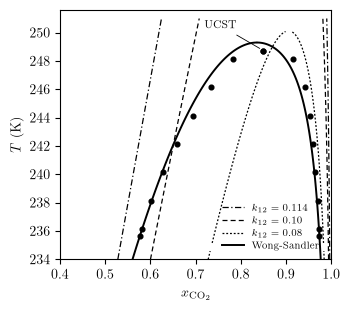

In [11]:
from matplotlib.ticker import MultipleLocator

def branches(model_of_T, T_lo, T_c, n=110):
    """Both liquid branches along the model's own three-phase line.

    The grid is quadratically clustered against T_c. An analytic equation of
    state closes its dome as sqrt(T_c - T), so on a uniform grid the last decimal
    of a kelvin carries the last 0.05 in composition and the two branches appear
    to stop short of each other -- a drawing artifact that looks like physics.
    """
    u = np.linspace(0.0, 1.0, n)
    Ts = T_c - (T_c - T_lo) * (1.0 - u) ** 2
    xI, xII = np.full(n, np.nan), np.full(n, np.nan)
    for i, T in enumerate(Ts):
        got = three_phase(model_of_T, T)
        if got is not None:
            _, xI[i], xII[i] = got
    return Ts, xI, xII

# The printed figure draws THREE one-fluid curves, not one -- k12 = 0.114, 0.10 and 0.08 -- so the
# reader can watch the whole curve slide as the single knob is turned. Each is taken up
# to its own critical end point, which is why 0.114 and 0.10 leave the top of the frame
# and 0.08 closes inside it.
VDW_CURVES = [(0.114, "0.114", (5, 2, 1, 2)), (0.10, "0.10", (4, 2.5)),
              (0.08, "0.08", (1.5, 1.5))]

T_TOP = 251.0
curves = []
for k, lab, dash in VDW_CURVES:
    m = PRMixture([co2, decane], kij=[[0.0, k], [k, 0.0]])
    T_c = top_of_three_phase_line(lambda T, m=m: m, 250.0, 320.0)[0]
    curves.append((lab, dash, *branches(lambda T, m=m: m, 234.0, min(T_c, T_TOP))))

Tg_ws, xI_ws, xII_ws = branches(ws_at, 234.0, T_ws)

fig, ax = plt.subplots(figsize=(3.6, 3.2))
for lab, dash, Tg, xI, xII in curves:
    for j, x in enumerate((xI, xII)):
        ax.plot(x, Tg, "k", lw=0.9, dashes=dash,
                label=(f"$k_{{12}} = {lab}$" if j == 0 else None))
for j, x in enumerate((xI_ws, xII_ws)):
    ax.plot(x, Tg_ws, "k-", lw=1.4, label="Wong-Sandler" if j == 0 else None)
ax.plot(XI_DATA,  T_DATA, "ko", ms=3.4)
ax.plot(XII_DATA, T_DATA, "ko", ms=3.4)

# Both the key and the UCST label go in the two genuinely empty regions -- the band
# under the data inside the Wong-Sandler dome, and the strip above it -- because a label
# landing on a line is the defect this project keeps hitting. Check any redraw.
ax.annotate("UCST", xy=(DATA[-1, 2], T_UCEP), xytext=(0.755, 250.5), fontsize=7.5,
            ha="center", va="center",
            arrowprops=dict(arrowstyle="-", lw=0.6, shrinkA=3, shrinkB=3, color="k"))
ax.legend(loc="lower left", bbox_to_anchor=(0.585, 0.02), fontsize=7,
          frameon=False, handlelength=2.2, borderaxespad=0.0, labelspacing=0.4)

ax.set_xlabel(r"$x_{\mathrm{CO_2}}$")
ax.set_ylabel(r"$T$ (K)")
ax.set_xlim(0.40, 1.0)
ax.set_ylim(234, T_TOP + 0.6)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(2))
fig.tight_layout()

for lab, _, Tg, xI, xII in curves:
    ok = np.isfinite(xI)
    closed = np.nanmin(xII) - np.nanmax(xI) < 0.02
    print(f"  k12 = {lab:>5s}: drawn to {Tg[ok].max():6.1f} K, branches "
          f"{np.nanmax(xI):.3f} / {np.nanmin(xII):.3f}"
          f"   {'closes in frame' if closed else 'leaves the frame open'}")
print(f"  Wong-Sandler : closes at {T_ws:6.1f} K, branches "
      f"{np.nanmax(xI_ws):.3f} / {np.nanmin(xII_ws):.3f}")
print(f"  measured     : closes at {T_UCEP:6.2f} K at x = {DATA[-1, 2]:.3f}")

os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Figure_11.2-6.pdf", dpi=300, bbox_inches="tight")
print("\n  wrote pdf/Figure_11.2-6.pdf")

**Four curves, one equation of state, one set of pure-component constants.** The only
difference between any of them is how $a_{\rm mix}$ and $b_{\rm mix}$ are formed from the
pure-component values.

**Read it as the figure intends — as a sequence.** The three one-fluid curves march to the
right as $k_{12}$ falls, and the argument is in the marching. At 0.114 the curve is far
left of the data and does not close in the frame at all. At 0.10 it is closer and still
open. At 0.08 it finally closes, at 250.1 K — a temperature the measurement would almost
accept — but by then its left branch has swung past the data to 0.741, and its apex sits
at $x = 0.90$ where the measurement says 0.850. **The curve slides; it does not change
shape.** That is what "no choice for the binary interaction parameter
will result in predictions that are in complete agreement" amounts to.

**A detail the printed figure cannot show, and this one can.** Its frame stops at
249 K, so whether the $k_{12} = 0.08$ curve ever closes is left hanging. It does, just
above the frame, and drawing to 251 K settles it. Extending the frame is the only
deliberate departure here from the printed layout.

**The Wong-Sandler curve is this notebook's, not the book's.** The book prints no
UNIQUAC parameters for it, so it has been refitted by the procedure the text describes —
the 235.65 K tie line, $k_{ij}$ from Table 9.4-1. It is not a trace of the printed line
and is not claimed to be.

## What to take from it

1. **A binary interaction parameter fitted to vapor-liquid data does not have to describe
   liquid-liquid equilibrium**, and here no value of it does. Liquid-liquid equilibrium is
   the most demanding test of a mixture model there is, because it depends on the
   *curvature* of the Gibbs energy rather than on its value.
2. **One constant sets the width of the two-phase region; nothing sets its skew.** The
   one-fluid rule makes $a_{\rm mix}$ a quadratic in composition, and a quadratic excess
   Gibbs energy is symmetric in a way this mixture is not. That is a structural limit, not
   a fitting failure, and it is why the three curves slide rather than reshape.
3. **The Wong-Sandler rule supplies exactly the freedom that was missing** — from two
   parameters at one temperature, not from fitting the curve.
4. **"Temperature-independent parameters" is a statement about the energies, not about
   $\tau$.** The two agree exactly at the temperature of the fit and nowhere else, so a
   converged fit at one temperature proves nothing about the parameterization. Whenever
   you carry a fitted activity-coefficient model to a new temperature, go back to the
   model's own definition of its parameter and check which quantity the source held
   constant.
5. **Score a model where it can be right.** Near a critical point every analytic model has
   the wrong exponent, so the last data point here measures the class of model, not this
   fit.

## Your turn

1. Refit at $k_{ij} = 0.135$ and redraw. How much better is it, and can you defend
   calling the result a prediction?
2. Add a fourth one-fluid curve at $k_{12} = 0.06$ and one at $0.13$. Does the family ever
   change shape, or only slide? Measure it: plot the width $x^{\rm II} - x^{\rm I}$ at
   235.65 K against the temperature at which each curve closes.
3. The reference isotherm is a choice. Fit the tie line at 244.15 K instead and predict
   235.65 K — an extrapolation downwards. Is it as good?
4. Illustration 11.3-2 computes the *three-phase* line for this same mixture with the
   one-fluid rule and reproduces the printed pressures to 0.06 bar. Why does the
   one-fluid rule do so well there and so badly here?
5. The three-phase pressure at 235.65 K comes out near 10.68 bar against a measured 10.58
   whatever $k_{ij}$ you choose. Show that this is pure CO₂'s vapor pressure from
   Peng-Robinson, and conclude that no mixing rule can repair it. (Section 10.3
   recommends PRSV for exactly this reason; try it, and check whether it helps here.)
6. Rebuild the Wong-Sandler model *once* at 235.65 K and evaluate it at 248.15 K without
   rebuilding. Catch the `FrozenParameterWarning`, and confirm the numbers match the "tau
   fixed" column above.